In [1]:
!pip install yfinance

In [2]:
!pip install seaborn plotly streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Stock ticker
ticker = "AAPL"

# Fetch stock data
df = yf.download(
    ticker,
    start="2024-01-01",
    end="2024-03-01"
)

# Keep only first 40 rows
df = df.head(40)

# Display dataset
df

/tmp/ipykernel_5487/1605052955.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700
2024-01-03,182.355591,183.968836,181.544015,182.325900,58414500
2024-01-04,180.039673,181.207533,179.020264,180.277196,71983600
2024-01-05,179.317154,180.880911,178.317544,180.118838,62379700
2024-01-08,183.652145,183.691743,179.633891,180.217821,59144500
2024-01-09,183.236465,183.246357,180.851240,182.029008,42841800
2024-01-10,184.275650,184.483482,182.028985,182.454572,46792900
2024-01-11,183.681793,185.126788,181.732047,184.622022,49128400


In [5]:
# ============================================================
# CELL 0C — Download stock data using yfinance
# Minimum 50 rows guaranteed
# ============================================================

# ── Settings — change these freely ──────────────────────────
TICKER = "AAPL"        # Try: TSLA, MSFT, GOOGL, AMZN, RELIANCE.NS
START  = "2023-01-01"  # Start date
END    = "2024-12-31"  # End date
# ────────────────────────────────────────────────────────────

print(f"📡 Downloading data for: {TICKER}")
print(f"   Period: {START} to {END}")
print("-" * 45)

raw = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)

# Flatten multi-level columns (yfinance sometimes returns them)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Standardise column names to lowercase
raw.columns = [c.strip().lower().replace(" ", "_") for c in raw.columns]

# Rename 'adj_close' if present
if "adj_close" not in raw.columns and "adj close" in raw.columns:
    raw.rename(columns={"adj close": "adj_close"}, inplace=True)

# Drop rows with all NaN
raw.dropna(how="all", inplace=True)

# ── Minimum row check ────────────────────────────────────────
MIN_ROWS = 50
if len(raw) < MIN_ROWS:
    print(f"⚠️  Only {len(raw)} rows found. Extending date range automatically...")
    raw = yf.download(TICKER, period="1y", auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns = [c.strip().lower().replace(" ", "_") for c in raw.columns]
    raw.dropna(how="all", inplace=True)

print(f"✅ Download complete!")
print(f"   Rows fetched  : {len(raw)}")
print(f"   Columns       : {list(raw.columns)}")
print(f"   Date range    : {raw.index.min().date()} → {raw.index.max().date()}")
print(f"   Minimum check : {'✅ PASSED' if len(raw) >= MIN_ROWS else '❌ FAILED'}")

📡 Downloading data for: AAPL
   Period: 2023-01-01 to 2024-12-31
---------------------------------------------
✅ Download complete!
   Rows fetched  : 501
   Columns       : ['adj_close', 'close', 'high', 'low', 'open', 'volume']
   Date range    : 2023-01-03 → 2024-12-30
   Minimum check : ✅ PASSED


In [6]:
# ============================================================
# CELL 0D — Preview raw data
# ============================================================

print("=" * 60)
print(f"  RAW DATA PREVIEW — {TICKER}")
print("=" * 60)

print(f"\n📋 FIRST 10 ROWS:")
display(raw.head(10).round(2))

print(f"\n📋 LAST 10 ROWS:")
display(raw.tail(10).round(2))

print(f"\n📐 SHAPE: {raw.shape[0]} rows × {raw.shape[1]} columns")

  RAW DATA PREVIEW — AAPL

📋 FIRST 10 ROWS:


,adj_close,close,high,low,open,volume
Date,,,,,,
2023-01-03,123.10,125.07,130.90,124.17,130.28,112117500
2023-01-04,124.37,126.36,128.66,125.08,126.89,89113600
2023-01-05,123.05,125.02,127.77,124.76,127.13,80962700
2023-01-06,127.57,129.62,130.29,124.89,126.01,87754700
2023-01-09,128.10,130.15,133.41,129.89,130.47,70790800
2023-01-10,128.67,130.73,131.26,128.12,130.26,63896200
2023-01-11,131.38,133.49,133.51,130.46,131.25,69458900
2023-01-12,131.30,133.41,134.26,131.44,133.88,71379600
2023-01-13,132.63,134.76,134.92,131.66,132.03,57809700



📋 LAST 10 ROWS:


,adj_close,close,high,low,open,volume
Date,,,,,,
2024-12-16,249.68,251.04,251.38,247.65,247.99,51694800
2024-12-17,252.10,253.48,253.83,249.78,250.08,51356400
2024-12-18,246.70,248.05,254.28,247.74,252.16,56774100
2024-12-19,248.43,249.79,252.00,247.09,247.50,60882300
2024-12-20,253.11,254.49,255.00,245.69,248.04,147495300
2024-12-23,253.88,255.27,255.65,253.45,254.77,40858800
2024-12-24,256.80,258.20,258.21,255.29,255.49,23234700
2024-12-26,257.61,259.02,260.10,257.63,258.19,27237100
2024-12-27,254.20,255.59,258.70,253.06,257.83,42355300



📐 SHAPE: 501 rows × 6 columns


In [7]:
# ============================================================
# CELL 0E — Display exactly 50 rows with styled formatting
# ============================================================

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.2f}".format)

# Pick 50 rows evenly spread across the full date range
step    = max(1, len(raw) // 50)
sample  = raw.iloc[::step].head(50).copy()

# Add a readable date column
sample.insert(0, "date", sample.index.date)

print("=" * 60)
print(f"  {TICKER} — 50 ROW DATA SAMPLE")
print(f"  Total rows in dataset: {len(raw)}")
print("=" * 60)
display(sample.round(2))

print(f"\n✅ Showing {len(sample)} rows")
print(f"   Earliest : {sample['date'].iloc[0]}")
print(f"   Latest   : {sample['date'].iloc[-1]}")

  AAPL — 50 ROW DATA SAMPLE
  Total rows in dataset: 501


,date,adj_close,close,high,low,open,volume
Date,,,,,,,
2023-01-03,2023-01-03,123.10,125.07,130.90,124.17,130.28,112117500
2023-01-18,2023-01-18,133.08,135.21,138.61,135.03,136.82,69672800
2023-02-01,2023-02-01,143.13,145.43,146.61,141.32,143.97,77663600
2023-02-15,2023-02-15,153.11,155.33,155.50,152.88,153.11,65573800
2023-03-02,2023-03-02,143.83,145.91,146.71,143.90,144.38,52238100
2023-03-16,2023-03-16,153.62,155.85,156.46,151.64,152.16,76161100
2023-03-30,2023-03-30,160.04,162.36,162.47,161.27,161.53,49501700
2023-04-14,2023-04-14,162.85,165.21,166.32,163.82,164.59,49386500
2023-04-28,2023-04-28,167.26,169.68,169.85,167.88,168.49,55275900



✅ Showing 50 rows
   Earliest : 2023-01-03
   Latest   : 2024-12-13


In [8]:
# ============================================================
# CELL 0F — Data quality check and column statistics
# ============================================================

print("=" * 60)
print("  DATA QUALITY REPORT")
print("=" * 60)

# Missing values
print("\n🔍 Missing values per column:")
missing = raw.isnull().sum()
for col, count in missing.items():
    status = "✅" if count == 0 else "⚠️"
    print(f"   {status}  {col:<15} : {count} missing")

# Data types
print("\n🔍 Data types:")
for col, dtype in raw.dtypes.items():
    print(f"   {col:<15} : {dtype}")

# Basic stats
print("\n📊 Descriptive statistics:")
display(raw.describe().round(2))

# Price summary
print("\n💰 Price summary:")
print(f"   Highest close  : ${raw['close'].max():.2f}  on {raw['close'].idxmax().date()}")
print(f"   Lowest  close  : ${raw['close'].min():.2f}  on {raw['close'].idxmin().date()}")
print(f"   Average close  : ${raw['close'].mean():.2f}")
print(f"   Avg daily vol  : {raw['volume'].mean():,.0f} shares")

# Assign cleaned dataframe for next cells
df = raw.copy()
print("\n✅ Data is clean and ready!")
print(f"   'df' is set with {len(df)} rows — carry this into all next cells.")

  DATA QUALITY REPORT

🔍 Missing values per column:
   ✅  adj_close       : 0 missing
   ✅  close           : 0 missing
   ✅  high            : 0 missing
   ✅  low             : 0 missing
   ✅  open            : 0 missing
   ✅  volume          : 0 missing

🔍 Data types:
   adj_close       : float64
   close           : float64
   high            : float64
   low             : float64
   open            : float64
   volume          : int64

📊 Descriptive statistics:


,adj_close,close,high,low,open,volume
count,501.00,501.00,501.00,501.00,501.00,501.00
mean,187.95,189.83,191.33,188.05,189.55,58198232.93
std,27.98,27.75,27.89,27.51,27.74,25134923.40
min,123.05,125.02,127.77,124.17,126.01,23234700.00
25%,169.93,172.07,173.54,170.52,171.76,44998500.00
50%,183.24,185.14,186.74,183.62,185.01,52517000.00
75%,212.60,214.24,216.78,211.92,213.93,64902300.00
max,257.61,259.02,260.10,257.63,258.19,318679900.00



💰 Price summary:
   Highest close  : $259.02  on 2024-12-26
   Lowest  close  : $125.02  on 2023-01-05
   Average close  : $189.83
   Avg daily vol  : 58,198,233 shares

✅ Data is clean and ready!
   'df' is set with 501 rows — carry this into all next cells.


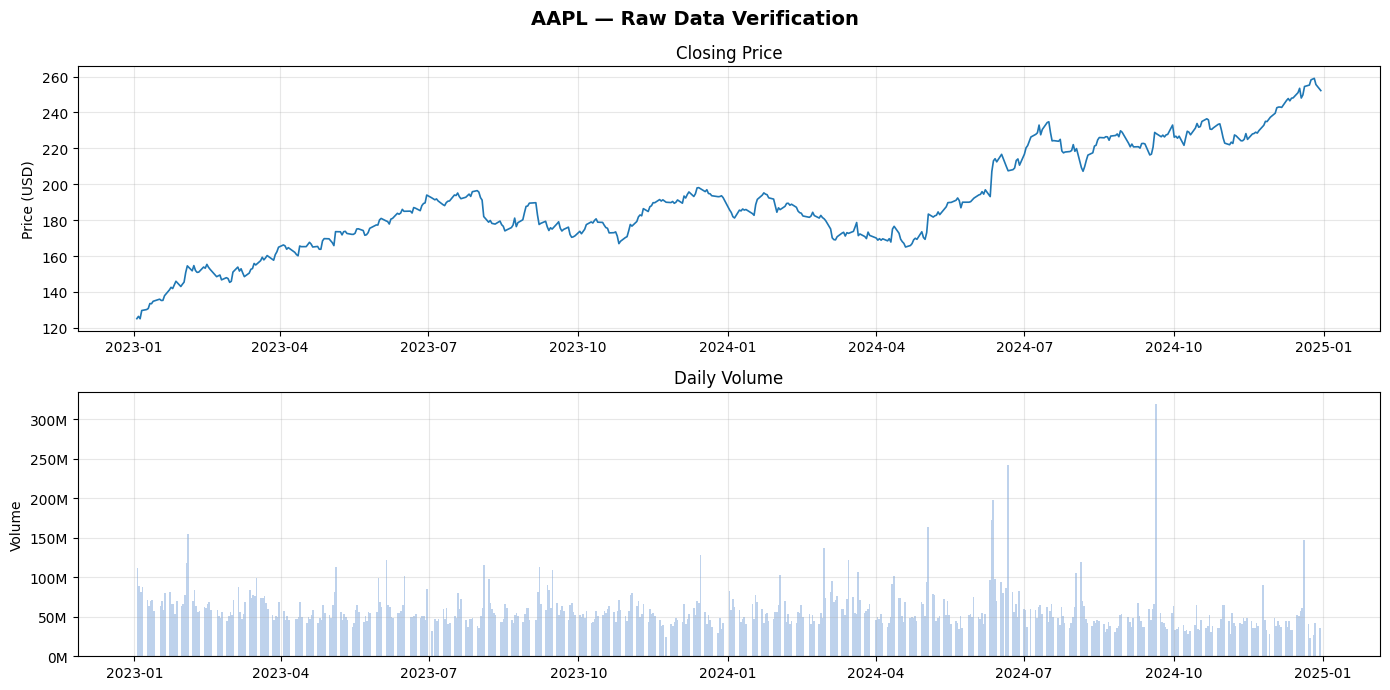

✅ Preview chart saved as 'AAPL_raw_data_preview.png'

🟢 All done! Now run Cell 3 onwards from the earlier notebook.


In [9]:
# ============================================================
# CELL 0G — Quick plot to visually verify the data
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f"{TICKER} — Raw Data Verification", fontsize=14, fontweight="bold")

# Closing price
axes[0].plot(df.index, df["close"], color="#1f77b4", linewidth=1.2)
axes[0].set_title("Closing Price")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df.index, df["volume"], color="#aec7e8", width=1, alpha=0.8)
axes[1].set_title("Daily Volume")
axes[1].set_ylabel("Volume")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{TICKER}_raw_data_preview.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Preview chart saved as '{TICKER}_raw_data_preview.png'")
print(f"\n🟢 All done! Now run Cell 3 onwards from the earlier notebook.")

In [10]:
raw["daily_return"] = raw["close"].pct_change()

In [11]:
raw.head()

,adj_close,close,high,low,open,volume,daily_return
Date,,,,,,,
2023-01-03,123.10,125.07,130.90,124.17,130.28,112117500,NaN
2023-01-04,124.37,126.36,128.66,125.08,126.89,89113600,0.01
2023-01-05,123.05,125.02,127.77,124.76,127.13,80962700,-0.01
2023-01-06,127.57,129.62,130.29,124.89,126.01,87754700,0.04
2023-01-09,128.10,130.15,133.41,129.89,130.47,70790800,0.00


In [13]:
raw["ma20"] = raw["close"].rolling(window=20).mean()

In [14]:
raw["ma50"] = raw["close"].rolling(window=50).mean()

In [15]:
raw.tail()

,adj_close,close,high,low,open,volume,daily_return,ma20,ma50
Date,,,,,,,,,
2024-12-23,253.88,255.27,255.65,253.45,254.77,40858800,0.00,245.03,235.38
2024-12-24,256.80,258.20,258.21,255.29,255.49,23234700,0.01,246.29,235.91
2024-12-26,257.61,259.02,260.10,257.63,258.19,27237100,0.00,247.49,236.42
2024-12-27,254.20,255.59,258.70,253.06,257.83,42355300,-0.01,248.52,236.89
2024-12-30,250.83,252.20,253.50,250.75,252.23,35557500,-0.01,249.27,237.29


In [16]:
volatility = raw["daily_return"].std() * np.sqrt(252)

print("Annualized Volatility:", volatility)

Annualized Volatility: 0.21365131712267327


In [18]:
# ============================================================
# CELL 5 — Daily returns and volatility analysis
# ============================================================

# ── Daily & cumulative returns ───────────────────────────────
df["daily_return"]      = df["close"].pct_change()
df["cumulative_return"] = (1 + df["daily_return"]).cumprod() - 1

# ── Rolling volatility (21-day annualised) ───────────────────
df["volatility_21d"] = df["daily_return"].rolling(window=21).std() * np.sqrt(252)

# ── Drawdown ─────────────────────────────────────────────────
rolling_max       = df["close"].cummax()
df["drawdown"]    = (df["close"] - rolling_max) / rolling_max

print("=" * 50)
print("RETURNS & RISK SUMMARY")
print("=" * 50)

total_return  = df["cumulative_return"].iloc[-1] * 100
ann_return    = ((1 + df["daily_return"].mean()) ** 252 - 1) * 100
ann_vol       = df["daily_return"].std() * np.sqrt(252) * 100
sharpe        = ann_return / ann_vol if ann_vol != 0 else 0
max_dd        = df["drawdown"].min() * 100
best_day      = df["daily_return"].max() * 100
worst_day     = df["daily_return"].min() * 100
positive_days = (df["daily_return"] > 0).sum()
negative_days = (df["daily_return"] < 0).sum()

print(f"\n  Total return         : {total_return:+.2f}%")
print(f"  Annualised return    : {ann_return:+.2f}%")
print(f"  Annualised volatility: {ann_vol:.2f}%")
print(f"  Sharpe ratio         : {sharpe:.2f}")
print(f"  Max drawdown         : {max_dd:.2f}%")
print(f"  Best single day      : {best_day:+.2f}%")
print(f"  Worst single day     : {worst_day:+.2f}%")
print(f"  Positive days        : {positive_days} ({positive_days/len(df)*100:.1f}%)")
print(f"  Negative days        : {negative_days} ({negative_days/len(df)*100:.1f}%)")

RETURNS & RISK SUMMARY

  Total return         : +101.65%
  Annualised return    : +45.67%
  Annualised volatility: 21.37%
  Sharpe ratio         : 2.14
  Max drawdown         : -16.71%
  Best single day      : +7.26%
  Worst single day     : -4.82%
  Positive days        : 281 (56.1%)
  Negative days        : 217 (43.3%)


In [19]:
highest_price = raw["high"].max()

lowest_price = raw["low"].min()

print("Highest Price:", highest_price)

print("Lowest Price:", lowest_price)

Highest Price: 260.1000061035156
Lowest Price: 124.16999816894531


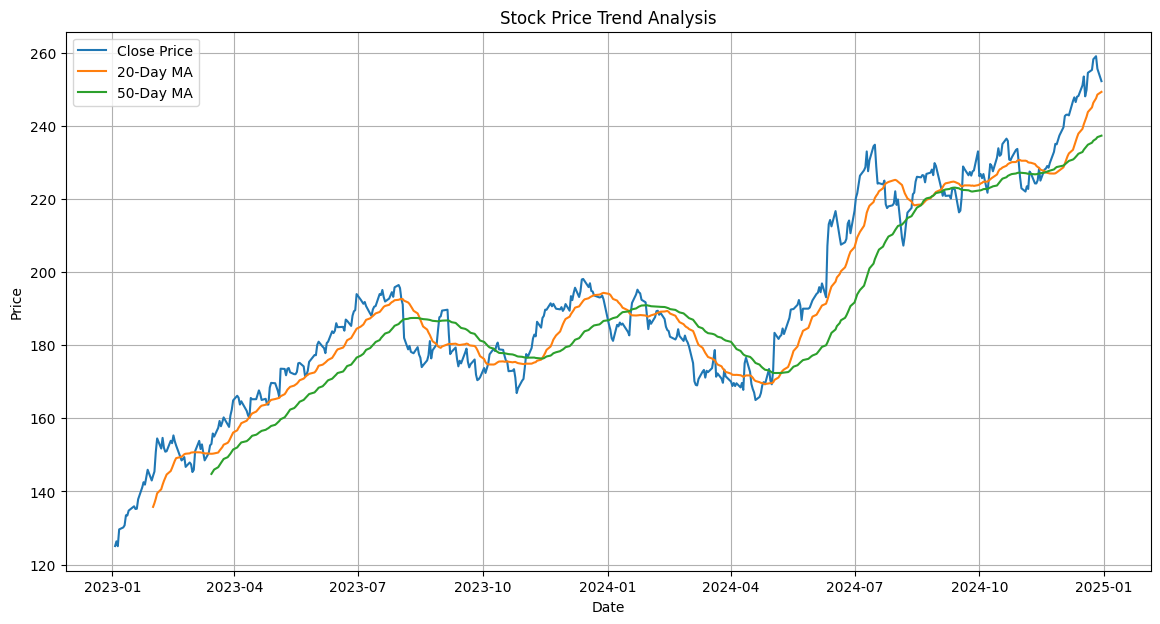

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(raw.index, raw["close"], label="Close Price")

plt.plot(raw.index, raw["ma20"], label="20-Day MA")

plt.plot(raw.index, raw["ma50"], label="50-Day MA")

plt.title("Stock Price Trend Analysis")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

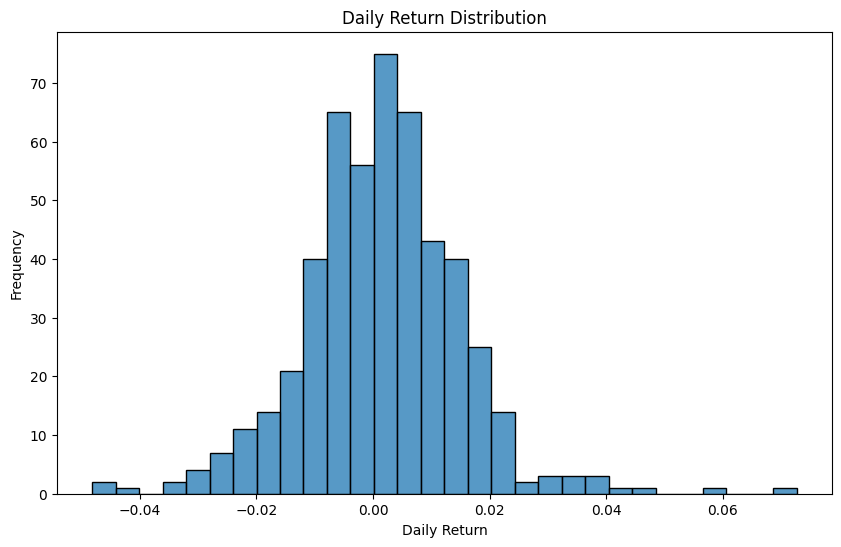

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(raw["daily_return"].dropna(), bins=30)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [25]:
report = {
    "Ticker": TICKER,
    "Rows": len(raw),
    "Highest Price": highest_price,
    "Lowest Price": lowest_price,
    "Volatility": volatility,
    "Average Daily Return": raw["daily_return"].mean()
}

report_df = pd.DataFrame([report])

report_df

,Ticker,Rows,Highest Price,Lowest Price,Volatility,Average Daily Return
0,AAPL,501,260.10,124.17,0.21,0.00


In [26]:
raw.to_csv("final_stock_dataset.csv")

In [28]:
report_df.to_csv("final_report.csv", index=False)